### Prediction and Update Formulae

Outcomes are given as a number from $0$ to $1$, where $0$ means the player/team on the left lost whilst $1$ means they won. If the outcome is $0.5$, we have a draw, and any number in between represents a win probability.

In [20]:
def expected_outcome(elo_a: float, elo_b: float, denominator: int = 400) -> float:
    rb_ra: float = (elo_b - elo_a) / denominator
    return 1 / (1 + 10 ** rb_ra)

In [22]:
def new_elos(elo_a: float, elo_b: float, outcome: float, k_factor: int = 16) -> tuple[float, float]:
    diff: float = k_factor * (outcome - expected_outcome(elo_a, elo_b))
    return elo_a + diff, elo_b - diff

In [203]:
def kelly_criterion(probability: float, odds: float = 2.0) -> float:
    return probability - (1 - probability) / (odds - 1)

### Load Data

First cell formats the raw data and extracts the teams, second cell splits data into training and test.

In [205]:
from pandas import DataFrame
import pandas as pd

raw: DataFrame = pd.read_csv("data/nba_team_reference.csv")
raw["points_ratio"] = raw["pts_home"] / (raw["pts_home"] + raw["pts_away"])
raw.drop(columns=["season_year", "team_id_home", "team_id_away", "pts_home", "pts_away", "home_win"], inplace=True)
raw.rename(columns={"game_id": "id", "game_date": "date", "team_abbreviation_home": "home", "team_abbreviation_away": "away"}, inplace=True)

teams: dict[str, float] = dict((team, 1000) for team in set(raw["home"].tolist() + raw["away"].tolist()))

assert len(teams) == 30

In [206]:
training: DataFrame = raw.sample(4 * len(raw) // 5).sort_values(by=["date"])
test:     DataFrame = raw[~raw["id"].isin(training["id"])].sort_values(by=["date"])

assert len(training) + len(test) == len(raw)
assert len(test["id"].isin(training["id"]).value_counts()) == 1

### Train

Go over each game in order and update team elos.

In [207]:
for row in training.itertuples():
    new_home, new_away = new_elos(teams[row.home], teams[row.away], row.points_ratio)
    teams[row.home] = new_home
    teams[row.away] = new_away

# Teams by Elo
print([ team[0] for team in sorted(teams.items(), key=lambda item: item[1], reverse=True) ])

['OKC', 'CLE', 'BOS', 'MIN', 'DEN', 'IND', 'HOU', 'GSW', 'LAC', 'NYK', 'MIL', 'MEM', 'LAL', 'SAC', 'DAL', 'DET', 'CHI', 'ORL', 'ATL', 'MIA', 'POR', 'TOR', 'PHX', 'SAS', 'PHI', 'NOP', 'BKN', 'UTA', 'CHA', 'WAS']


### Test

In [208]:
predictions: DataFrame = test.copy()
predictions["prob"] = predictions.apply(lambda row: expected_outcome(teams[row["home"]], teams[row["away"]]), axis=1)
predictions.apply(lambda row: kelly_criterion(row["prob"] if row["prob"] > 0.5 else (1 - row["prob"])), axis=1)
predictions["kelly_bet"] = predictions.apply(lambda row: kelly_criterion(row["prob"] if row["prob"] > 0.5 else (1 - row["prob"])), axis=1)
predictions["correct"] = (predictions["points_ratio"] > 0.5) == (predictions["prob"] > 0.5)

kelly_balances: list[float] = [ 10_000.0 ]

for row in predictions.itertuples():
    kelly_balances.append(kelly_balances[-1] + kelly_balances[-1] * row.kelly_bet * (1 if row.correct else -1))

success: dict[bool, int] = predictions["correct"].value_counts().to_dict()
print(f"Win Rate: {success[True] / (success[True] + success[False])}, Kelly Balance: {kelly_balances[-1]}")

Win Rate: 0.5484048404840484, Kelly Balance: 6465728.2300685095, Manthan Balance: 6465728.2300685095


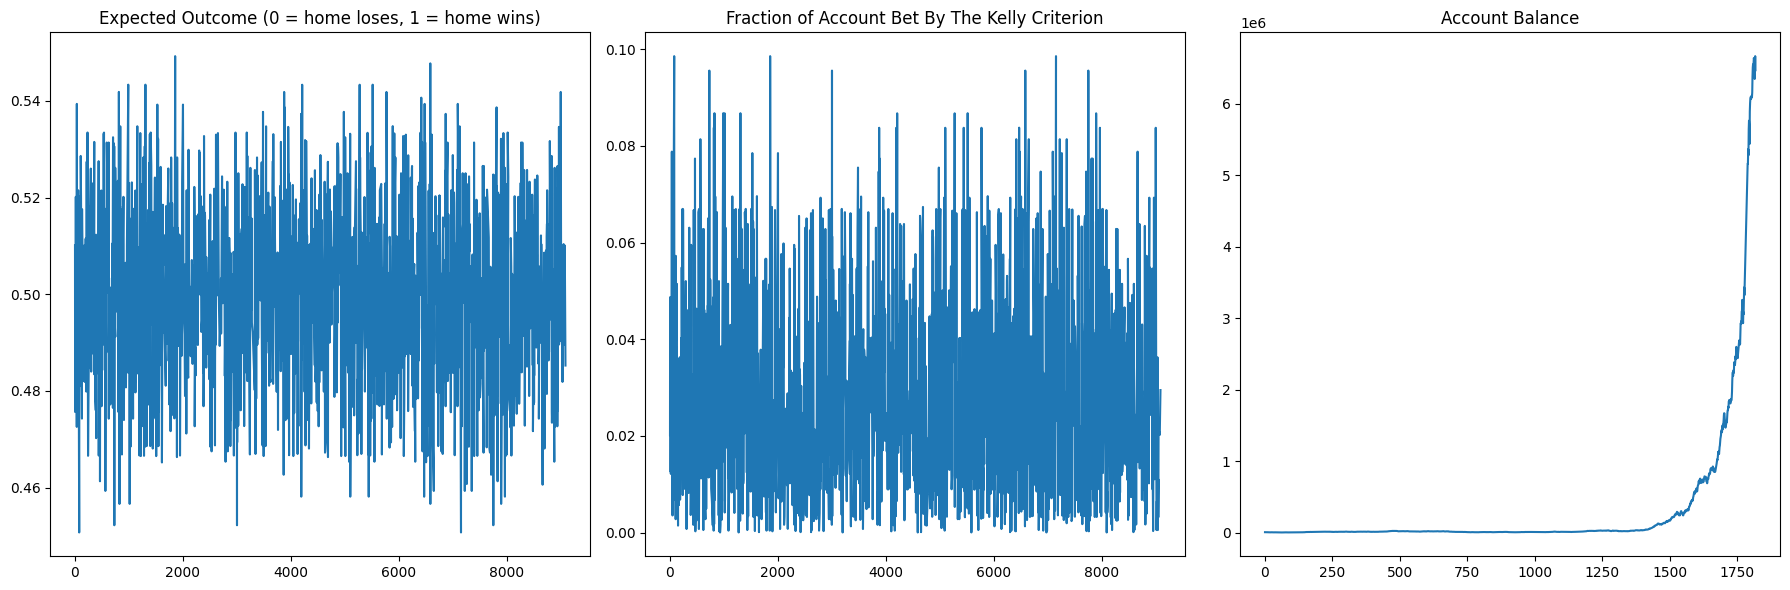

In [221]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].plot(predictions.prob)
axs[0].set_title("Expected Outcome (0 = home loses, 1 = home wins)")

axs[1].plot(predictions.kelly_bet)
axs[1].set_title("Fraction of Account Bet By The Kelly Criterion")

axs[2].plot(kelly_balances)
axs[2].set_title("Account Balance")

plt.tight_layout()
plt.show()